# Day 3 — Hands-on: Linear Regression and Logistic Regression
**Long-Jing Hsu, PhD**

This notebook demonstrates the basic scikit-learn workflow — *load data → split → fit → predict → evaluate* — on two kinds of supervised learning problems (regression and classification) using the [PetFinder Adoption Prediction](https://www.kaggle.com/competitions/petfinder-adoption-prediction) dataset.

**Contents:**

- [Setup](#setup)
- [A. Regression](#a-regression)
- [B. Classification](#b-classification)
- [Final Challenge](#final-challenge)
- [Recap](#recap)



### Running the notebook

Run cells **top to bottom**. The notebook reuses variable names (`X`, `y`, `feature_cols`, `df`) across sections, so jumping around or rerunning out of order will produce confusing results. If you get lost: **Kernel → Restart & Run All**.

## Setup

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    r2_score,
    accuracy_score, confusion_matrix, precision_score, recall_score,
)


### Load the petfinder dataset

`petfinder.csv` is a copy of the [PetFinder competition](https://www.kaggle.com/competitions/petfinder-adoption-prediction) dataset. The cell below loads it directly from the course GitHub repository, so there is nothing to download.


In [25]:
url = "https://raw.githubusercontent.com/elleobrien/MIDAS_summer_academy_student/main/day03/petfinder.csv"
df = pd.read_csv(url)

# Keep only the columns we'll actually use in this notebook, and drop any rows
# with missing values in those columns. Done once, up front, so every section
# operates on the same cleaned dataframe.
needed = [
    "Age", "Fee", "PhotoAmt", "VideoAmt", "Quantity",
    "Gender", "MaturitySize", "FurLength",
    "Vaccinated", "Dewormed", "Sterilized", "Health",
    "AdoptionSpeed", "Type",
]
df = df.dropna(subset=needed)[needed].reset_index(drop=True)

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (14993, 14)


,Age,Fee,PhotoAmt,VideoAmt,Quantity,Gender,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,AdoptionSpeed,Type
0,3,100,1.0,0,1,1,1,1,2,2,2,1,2,2
1,1,0,2.0,0,1,1,2,2,3,3,3,1,0,2
2,1,0,7.0,0,1,1,2,2,1,1,2,1,3,1
3,4,150,8.0,0,1,2,2,1,1,1,2,1,2,1
4,1,0,3.0,0,1,1,2,1,2,2,2,1,2,1


<details>
<summary><strong>Data dictionary</strong> (click to expand)</summary>

<br>

Source: [Kaggle PetFinder Adoption Prediction · Data](https://www.kaggle.com/competitions/petfinder-adoption-prediction/data). The 14 columns we use in this notebook:

| Column | Meaning |
| --- | --- |
| `Type` | Type of animal: `1` = Dog, `2` = Cat |
| `Age` | Age of pet when listed, **in months** |
| `Gender` | `1` = Male, `2` = Female, `3` = Mixed (when the profile is a group) |
| `MaturitySize` | Size at maturity: `0` = Not Specified, `1` = Small, `2` = Medium, `3` = Large, `4` = Extra Large |
| `FurLength` | `0` = Not Specified, `1` = Short, `2` = Medium, `3` = Long |
| `Vaccinated` | `1` = Yes, `2` = No, `3` = Not Sure |
| `Dewormed` | `1` = Yes, `2` = No, `3` = Not Sure |
| `Sterilized` | Spayed / neutered: `1` = Yes, `2` = No, `3` = Not Sure |
| `Health` | `0` = Not Specified, `1` = Healthy, `2` = Minor Injury, `3` = Serious Injury |
| `Quantity` | Number of pets in this listing |
| `Fee` | Adoption fee in MYR (Malaysian Ringgit). `0` = free |
| `VideoAmt` | Number of videos uploaded for this listing |
| `PhotoAmt` | Number of photos uploaded for this listing |
| `AdoptionSpeed` | Target: `0` = same-day, `1` = within 1 week, `2` = within 1 month, `3` = 1–3 months, `4` = not adopted after 100 days |

</details>

### Familiarize yourself with the dataset

Before modeling anything, it's typical to get a feel for the data. Take a few moments to familiarize yourself with what's present- what _type_ of data is each feature (column)? Does it represent a category or a continuous value? What are some typical values? In particular, look into two targets we're going to try to predict, **`Fee`** and **`AdoptionSpeed`**. Do you have any guesses what features might be related to those prediction targets?


In [26]:
# Space to explore - consider displaying some summary statistics, or plotting some of the columns against each other.

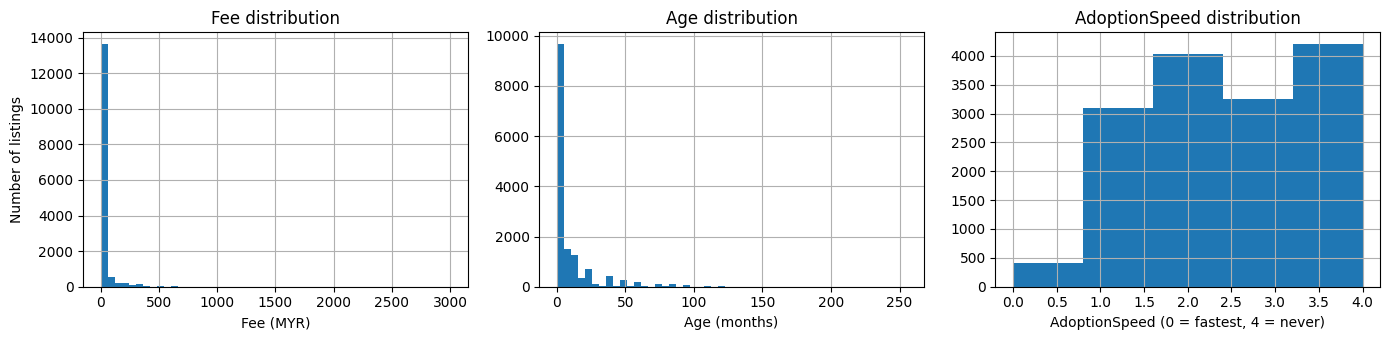

In [27]:
# Side-by-side histograms of Fee, Age, and AdoptionSpeed.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

df["Fee"].hist(bins=50, ax=axes[0])
axes[0].set_title("Fee distribution")
axes[0].set_xlabel("Fee (MYR)")
axes[0].set_ylabel("Number of listings")

df["Age"].hist(bins=50, ax=axes[1])
axes[1].set_title("Age distribution")
axes[1].set_xlabel("Age (months)")

df["AdoptionSpeed"].hist(bins=5, ax=axes[2])
axes[2].set_title("AdoptionSpeed distribution")
axes[2].set_xlabel("AdoptionSpeed (0 = fastest, 4 = never)")

plt.tight_layout()
plt.show()


**What do you notice?**
- For each variable, what range do typical values fall in?
- Do the distributions have spikes? Why might that be?



## A. Regression

Linear regression is one of the simplest ways to model the relationship between continuous variables. Did you know it can be used for machine learning, too? Let's see an example.

**The question:** can we predict the **adoption fee** for a pet from its other listing attributes?

We'll focus on **paid listings only** (`Fee > 0`).




In [28]:
# Drop any listings with a fee of 0. Resetting the index is optional, but it makes the output easier to read.
df_part1 = df[df["Fee"] > 0].reset_index(drop=True)

# Print out how many listings have a fee greater than 0, and what percentage of all listings that represents.
print(f"Paid listings (Fee > 0): {len(df_part1)} "
      f"({100 * len(df_part1) / len(df):.1f}% of all listings)")


Paid listings (Fee > 0): 2330 (15.5% of all listings)


### 1. The train/test split
For simplicity, we will start with a **univariate** model *(univariate = one predictor)* — we will use `Age` as the one predictor of the target `Fee`. We can add more predictors later.




<details>
<summary><strong>Note: should EDA happen <em>before</em> the split?</strong></summary>

<br>

In production ML, you'd typically only look at the **training** portion of your data during EDA. Peeking at the full dataset (including what will eventually become the test set) can subtly bias your modeling choices — for example, picking features or transformations based on patterns that wouldn't hold on unseen data. This is sometimes called **EDA leakage**.

We did EDA on the full `df` here because the dataset is fixed and the model is simple — we're not making selection decisions based on what we saw. For a real project, doing EDA on the training portion only is the safer habit.

</details>


First, we isolate our predictor variables and target. It's a convention to use `X` as the matrix of predictor variables (in this case, it's just the one predictor, `Age`) and `y` as the vector of target variable values.

In [29]:
# Isolate our predictor variables and target
X = df_part1[["Age"]] # By convention, X is the matrix of predictor variables (features)
y = df_part1["Fee"] # By convention, y is the vector of target variable values



Next, we **split** both `X` and `y` into train and test sets. In this case, we will use an 80-20 split, meaning 80% of the data is randomly selected to be in the training dataset, and the remaining 20% of data is in the test set.

In [30]:
# random_state=42 -> fixed seed so the split is reproducible (everyone gets the same rows)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Train size: 1864
Test size : 466


In [31]:
# See for yourself- what shape is y_train? y_test? Can you see why these numbers make sense, given the train/test split we just did?
# Try: print(y_train.shape, y_test.shape)


### 2. Fit the model and predict

Every scikit-learn model follows the same pattern: first, we _train_ the model using `.fit(X, y)`. Notice that at this stage, nothing comes _out_ of the model. It's just learning from the training data we pass it.

In [32]:
model = LinearRegression() # Create a LinearRegression model object. This is just an empty model, it hasn't learned anything yet.
model.fit(X_train, y_train) # Fit the model on the training data.

LinearRegression()

Now, we can use the trained model to make predictions on the test set. Notice how we are using `.predict()` and passing in the test dataset. Think carefully- what does the variable `X_test` hold? What values is it and where did they come from?

In [33]:
y_pred = model.predict(X_test) # save the model predictions as y_pred

# Let's inspect some of the predictions, and compare them to the true values
print("First 5 predictions:", y_pred[:5].round(2))
print("First 5 true values:", y_test.values[:5])


First 5 predictions: [122.03 117.25 117.25 120.43 117.25]
First 5 true values: [100  20  40  50  50]


### 3. Evaluate the model

We will use the R² metric as a measure of model fit here. Remember that R² = 1.0 is perfect fit; R² = 0.0 means the model did no better than predicting the **mean fee** for every listing. We can calculate the model fit on both the training data and the test data. Which one do you think will be higher?


In [34]:
# Predict on both sets. y_pred (test predictions) already exists from step 2.
y_train_pred = model.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test,  y_pred)

print(f"R² (train): {r2_train:.4f}")
print(f"R² (test) : {r2_test:.4f}")


R² (train): 0.0452
R² (test) : 0.0217


In machine learning, what we care about is how the model performs on the _test_ dataset. It's all about how well the model performs on data it hasn't seen while training! R² will often be higher on your training dataset.

## Understanding what just happened

Now we plot the fitted regression line on top of the training data, and *also* on top of the held-out test data. **It's the same line in both panels** — the model (the line of best fit) was fit on the training dataset. The right-hand panel just shows what happens when we ask that same line to predict pets it has never seen.

In the example above, `sklearn` fit a line of the form:

$$ \widehat{\text{Fee}} = w_0 + w_1 \cdot \text{Age} $$

- The **slope** `w_1` tells you how the predicted fee changes per extra month of age. Positive → older pets cost more.
- The **intercept** `w_0` is the predicted fee at `Age = 0` (a newborn).

> **Did the sign of the slope surprise you?** Most people expect puppies and kittens to cost more, but in *paid* listings the slope says the opposite.


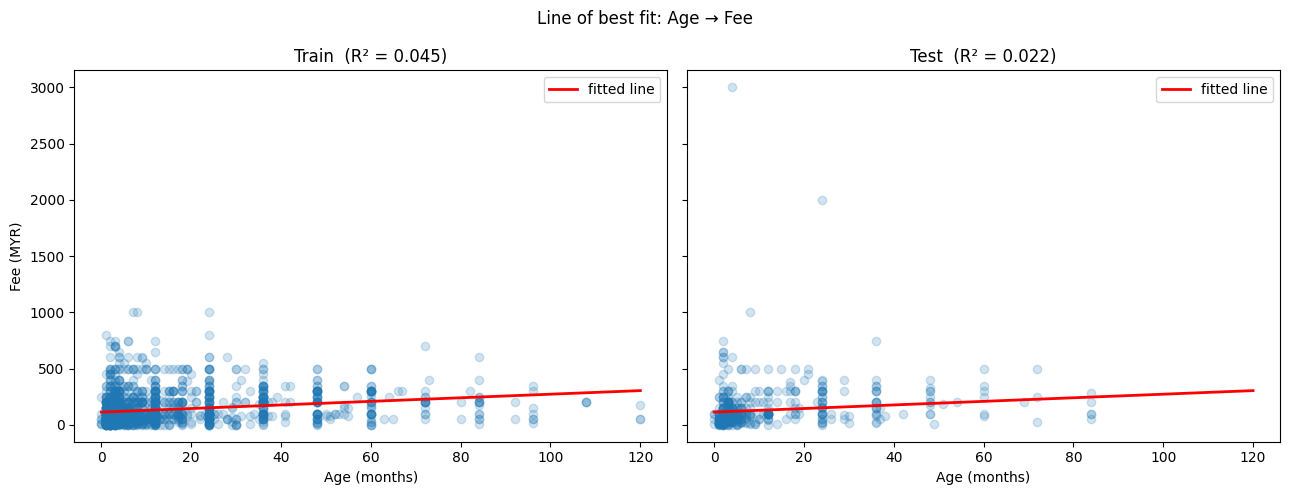

Slope     (per month of age): +1.592 MYR
Intercept (Fee at Age = 0)  : 114.1 MYR


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# The fitted line is identical in both panels -- compute it once over the
# observed Age range.
age_grid = pd.DataFrame(
    {"Age": np.linspace(X_train["Age"].min(), X_train["Age"].max(), 100)}
)
line_y = model.predict(age_grid)

# Left panel: TRAINING data with the line that was fit to it.
axes[0].scatter(X_train["Age"], y_train, alpha=0.2)
axes[0].plot(age_grid["Age"], line_y, "r-", linewidth=2, label="fitted line")
axes[0].set_title(f"Train  (R² = {r2_train:.3f})")
axes[0].set_xlabel("Age (months)")
axes[0].set_ylabel("Fee (MYR)")
axes[0].legend()

# Right panel: TEST data the model never saw, with THE SAME line.
axes[1].scatter(X_test["Age"], y_test, alpha=0.2)
axes[1].plot(age_grid["Age"], line_y, "r-", linewidth=2, label="fitted line")
axes[1].set_title(f"Test  (R² = {r2_test:.3f})")
axes[1].set_xlabel("Age (months)")
axes[1].legend()

plt.suptitle("Line of best fit: Age → Fee")
plt.tight_layout()
plt.show()

print(f"Slope     (per month of age): {model.coef_[0]:+.3f} MYR")
print(f"Intercept (Fee at Age = 0)  : {model.intercept_:.1f} MYR")


Remember- the red line is identical in both panels of the plot! Can you see where that line might not be the best fit for the test data?

### Practice — your turn: add more features

So far we've used only **`Age`** as a predictor of `Fee`. But if we use more features, we may get better results. Let's see if telling the model more about each pet helps it price them.

**Your task:** rebuild the model using **`Age`, `MaturitySize`, and `Type`** as features (still on the same `df_part1` subset, same target `Fee`, same `random_state=42` split).

Steps:
1. Build `X` with the three columns and `y` = `df_part1["Fee"]`
2. Train / test split with `random_state=42`
3. Fit `LinearRegression`
4. Report **R²** on both train and test (like the demo's step 3)

Then compare to the univariate model:
- Did test `R²` go up?
- By how much?
- Does this match your intuition for how informative the new features were?

**Stretch:** try using *all* of the numeric features (`Age`, `PhotoAmt`, `VideoAmt`, `Quantity`, `Gender`, `MaturitySize`, `FurLength`, `Vaccinated`, `Dewormed`, `Sterilized`, `Health`, `Type`). Does adding on more features keep helping, or does test R² plateau?

Worked solution: `day03_sklearn_workflow_teacher.ipynb`.

In [36]:
# TODO: refit with Age, MaturitySize, and Type as features (still using df_part1 and Fee).
# Then compare train and test R^2 to the univariate model above.


## B. Classification

**Logistic regression** is the classification counterpart to linear regression. Instead of a number, the model predicts a **class label**.

### Binary target

We'll convert `AdoptionSpeed` (0–4) into a binary target:
- `1` → adopted within 30 days (`AdoptionSpeed` ∈ {0, 1, 2})
- `0` → adopted later or not at all (`AdoptionSpeed` ∈ {3, 4})

| Value | Meaning |
| :---: | --- |
| **0** | Adopted the **same day** it was listed |
| **1** | Adopted within **1–7 days** (first week) |
| **2** | Adopted within **8–30 days** (first month) |
| **3** | Adopted within **31–90 days** (2nd–3rd month) |
| **4** | **Not adopted** after 100 days |

(Quirk of the dataset: no pets fall in the 91–99-day window — that's why 100 is the cutoff.)


### 1. Build target and check class balance

In [37]:
# Build a binary target: was the pet adopted within 30 days?
df["AdoptedWithin30d"] = (df["AdoptionSpeed"] <= 2).astype(int)

# A small set of numeric features to feed the classifier. PetFinder already encodes
# its categorical columns as integer codes (Type 1/2, Gender 1/2/3, ...), so we can
# pass them straight to scikit-learn. AdoptionSpeed is deliberately NOT here -- it's
# the target; including it would be data leakage.
feature_cols = [
    "Age", "Fee", "PhotoAmt", "VideoAmt", "Quantity",
    "Gender", "MaturitySize", "FurLength",
    "Vaccinated", "Dewormed", "Sterilized", "Health",
]

X = df[feature_cols]
y = df["AdoptedWithin30d"]

# Class balance -- what fraction of pets fall in each class?
balance = y.value_counts(normalize=True).round(3)
balance.index = ["0 = later/not adopted", "1 = within 30 days"]
print("Class balance:")
print(balance)


Class balance:
0 = later/not adopted    0.503
1 = within 30 days       0.497
Name: proportion, dtype: float64


### 2. Split, fit, predict

> `stratify=y` keeps the class proportions the same in train and test. Important when classes are imbalanced — without it, the test set could end up with weird proportions just by chance.
>
> `max_iter=1000` raises the cap on the optimizer's iterations. Logistic regression is fit *iteratively*; the default 100 sometimes isn't enough for unscaled data (you'd see a `ConvergenceWarning`).

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"Predicted on {len(y_pred)} test pets.")

Predicted on 2999 test pets.


### 3. Evaluate with four classification metrics

Accuracy alone can be misleading (especially for imbalanced classes). Look at all four together to get the real picture.

In [39]:
# Accuracy: overall fraction of correct predictions.
acc = accuracy_score(y_test, y_pred)
n_correct = (y_pred == y_test).sum()
print(f"Accuracy: {acc:.3f}  ({n_correct} / {len(y_test)} correct)")

Accuracy: 0.579  (1735 / 2999 correct)


In [40]:
# Confusion matrix: rows = actual class, columns = predicted class.
# Diagonal = correct; off-diagonal = mistakes.
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["actual: later/not", "actual: within 30d"],
    columns=["pred: later/not", "pred: within 30d"],
)
print("Confusion matrix:")
print(cm_df)

Confusion matrix:
                    pred: later/not  pred: within 30d
actual: later/not               775               716
actual: within 30d              548               960


The diagonal (upper left and lower right) is where the model is right. Add them: 775 + 961 = 1,736 correct out of 2,999 → that's the 57.9% accuracy from the previous cell.

In [41]:
# Precision: when the model says "within 30d", how often is it right?
#   -> high precision means few false alarms.
# Recall (a.k.a. sensitivity): of all pets that ACTUALLY got adopted within 30d,
#   how many did the model catch?  -> high recall means few misses.
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
print(f"Precision           : {prec:.3f}")
print(f"Recall (sensitivity): {rec:.3f}")

Precision           : 0.573
Recall (sensitivity): 0.637


Precision: 0.573 → "When the model says yes, it's right 57% of the time."
Recall: 0.637 → "The model catches 64% of the pets that really do get adopted fast."

the model is roughly as bad in both directions — it makes lots of false alarms AND misses lots of real fast-adoption cases. Not a strong classifier. Both numbers being close to 0.5 echoes the accuracy of 0.579 you saw: the model is barely better than a coin flip on this task. (Which matches what the features can support — these 12 fields just don't carry much signal about adoption speed.)

### Practice — your turn: predict whether the pet was **adopted at all**

The demo asked "adopted within 30 days?" Now flip the question to a broader one: **"adopted at all?"**

- `1` → adopted at some point (`AdoptionSpeed` ∈ {0, 1, 2, 3})
- `0` → not adopted after 100 days (`AdoptionSpeed` == 4)

Steps:
1. Build a new binary target column from `AdoptionSpeed` (`!= 4`)
2. Train / test split with `stratify=y`
3. Fit `LogisticRegression(max_iter=1000)`
4. Predict and report **all four metrics from the demo**: accuracy, confusion matrix, precision, recall.

Then compare with the demo:
- Accuracy is higher here. Does that mean the model is *better*, or is something else going on?
- What do the confusion matrix and precision/recall tell you that accuracy alone might hide?

Worked solution: `day03_sklearn_workflow_teacher.ipynb`.

In [42]:
# TODO: predict "adopted at all" (AdoptionSpeed != 4)
# Hint: df["AdoptedAtAll"] = (df["AdoptionSpeed"] != 4).astype(int)
#
# Mirror the demo's structure -- use a SEPARATE cell for each step so you can
# see each output on its own:
#   1. Build the target and check class balance
#   2. Split, fit, predict
#   3. Accuracy
#   4. Confusion matrix
#   5. Precision and recall
# (Press B in a notebook to add a new cell below.)



## Final Challenge — your turn to explore

A shelter wants to know: **which feature in a listing most affects whether a pet gets adopted within 30 days?**

Use only methods from this notebook to investigate, then write up your finding in 1–2 sentences. There's more than one valid approach — pick whatever feels natural to you.

When you're done, share what you found with the class. Different people may reach different conclusions, and that's part of the discussion.

In [43]:
# CHALLENGE: which feature most affects AdoptedWithin30d?
# Pick an approach (or design your own) and run it here.
#
# Stuck? Here's one rope to climb (there are others):
#   - Try the classification workflow above but with only ONE feature at a time in X.
#     The single feature with the highest test accuracy is one candidate
#     for "most predictive."
#     Skeleton:
#         for feat in feature_cols:
#             X = df[[feat]]
#             # ... split, fit, score ...



## Recap

You ran two of the most common scikit-learn workflows end-to-end, **then practiced each one** on a slightly different question — all on the PetFinder dataset:

| Task | Model | Demo target | Practice target |
| --- | --- | --- | --- |
| Regression | `LinearRegression` | `Fee` from `Age` (univariate, paid listings only) | Add more features (multivariate) |
| Classification | `LogisticRegression` | Adopted within 30 days? | Adopted at all? |

**The pattern is the same every time:** load → split → fit → predict → evaluate. Once this loop feels familiar, swapping in a different model (or threshold, or `k`) is mostly a one-line change.
